**Cell 1 — Imports and configuration**

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt

OUTPUT_DIR = os.getcwd()

SEED = 42
N = 120
BLOCK_SIZE = 20
POT_PERCENTILE = 90

**Cell 2 — Generate synthetic loss data**

In [14]:
np.random.seed(SEED)

returns = np.random.randn(N)
losses = np.maximum(-returns, 0)

num_blocks = N // BLOCK_SIZE

**Cell 3 — Compute Block Maxima statistics**

In [15]:
block_maxima = [
    np.max(losses[i*BLOCK_SIZE:(i+1)*BLOCK_SIZE]) for i in range(num_blocks)
]
block_max_indices = [
    i*BLOCK_SIZE + np.argmax(losses[i*BLOCK_SIZE:(i+1)*BLOCK_SIZE])
    for i in range(num_blocks)
]

print(f"Block maxima ({num_blocks} blocks of size {BLOCK_SIZE}):")
print(block_maxima)

Block maxima (6 blocks of size 20):
[1.913280244657798, 1.9596701238797756, 1.763040155362734, 2.6197451040897444, 1.4635149481321186, 1.9187712152990415]


**Cell 4 — Compute POT (Peaks Over Threshold) statistics**

In [16]:
u = np.percentile(losses[losses > 0], POT_PERCENTILE)
pot_indices = np.where(losses > u)[0]
pot_values = losses[pot_indices]

print(f"Threshold u (P{POT_PERCENTILE}): {u:.4f}")
print(f"Number of exceedances: {len(pot_values)}")

Threshold u (P90): 1.6264
Number of exceedances: 7


**Cell 5 — Plotting helper functions**

In [17]:
def set_axes_at_origin(ax):
    ax.spines["left"].set_position("zero")
    ax.spines["bottom"].set_position("zero")
    ax.spines["right"].set_color("none")
    ax.spines["top"].set_color("none")
    ax.xaxis.set_ticks_position("bottom")
    ax.yaxis.set_ticks_position("left")
    ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False)
    ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False)

def draw_block_maxima(ax, losses, block_maxima, block_max_indices, num_blocks, block_size, ymax):
    ax.stem(range(len(losses)), losses, linefmt="gray", markerfmt=" ", basefmt=" ")
    ax.scatter(block_max_indices, block_maxima, color="black", s=30, zorder=3)
    ax.set_xlim(0, len(losses))
    ax.set_ylim(0, ymax)
    block_ticks = [(i + 0.5) * block_size for i in range(num_blocks)]
    block_labels = [str(i + 1) for i in range(num_blocks)]
    ax.set_xticks(block_ticks)
    ax.set_xticklabels(block_labels)
    ax.set_yticks([])
    set_axes_at_origin(ax)

def draw_pot(ax, losses, pot_indices, pot_values, u, ymax):
    ax.stem(range(len(losses)), losses, linefmt="gray", markerfmt=" ", basefmt=" ")
    ax.axhline(u, color="black", linestyle="--")
    ax.scatter(pot_indices, pot_values, color="black", s=30, zorder=3)
    for i, (idx, val) in enumerate(zip(pot_indices, pot_values), start=1):
        ax.text(idx, val + 0.05, f"$x_{i}$", fontsize=9, ha="center")
    ax.text(2, u + 0.05, "$u$", fontsize=10)
    ax.set_xlim(0, len(losses))
    ax.set_ylim(0, ymax)
    ax.set_xticks([])
    ax.set_yticks([])
    set_axes_at_origin(ax)

**Cell 6 — Save individual plots**

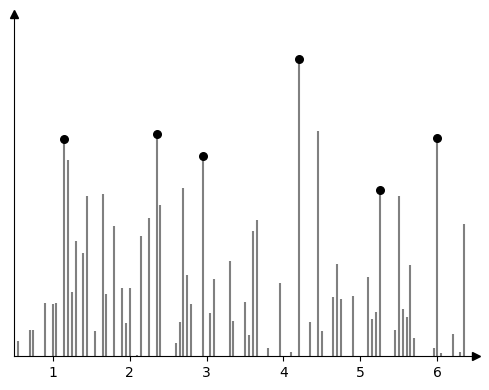

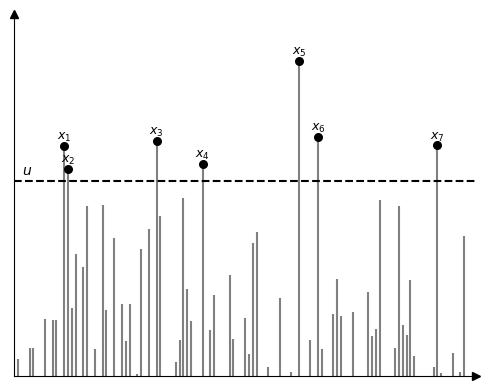

Individual plots saved.


In [18]:
ymax = losses.max() * 1.15

plot_configs = [
    (lambda ax: draw_block_maxima(ax, losses, block_maxima, block_max_indices, num_blocks, BLOCK_SIZE, ymax),
     "MSR_BlockMaxima.png"),
    (lambda ax: draw_pot(ax, losses, pot_indices, pot_values, u, ymax),
     "MSR_POT.png"),
]

for draw_fn, fname in plot_configs:
    fig_single, ax_single = plt.subplots(figsize=(5, 4))
    draw_fn(ax_single)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=300, bbox_inches="tight", transparent=True)
    plt.show()
    plt.close()

print("Individual plots saved.")